# Supervised Learning Models and Metrics

In [ ]:
from util.met_cleaning import clean_met_data
from util.preprocessing import supervised_preprocessing, supervised_feature_importance, ablation_testing
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay
from sklearn.model_selection import cross_validate, StratifiedKFold
# from sklearn.model_selection import RandomizedSearchCV
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
from joblib import load#, dump
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

In [2]:
df = clean_met_data()

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 484956 entries, 1 to 900748
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   is_significant       484956 non-null  bool  
 1   department           484956 non-null  object
 2   object_name          482690 non-null  object
 3   title                456153 non-null  object
 4   portfolio            26514 non-null   object
 5   artist_display_name  282513 non-null  object
 6   country_mapped       442664 non-null  object
 7   medium               477741 non-null  object
 8   artist_gender        106482 non-null  object
 9   culture              208190 non-null  object
 10  artist_nationality   282513 non-null  object
 11  access_year          481094 non-null  object
 12  age                  484956 non-null  int64 
dtypes: bool(1), int64(1), object(11)
memory usage: 48.6+ MB
None


In [4]:
print(df.describe())

             age
count 484956.000
mean     721.086
std     1710.259
min    -2975.000
25%      134.000
50%      225.000
75%      490.000
max   402025.000


([<matplotlib.patches.Wedge at 0x14748b380>,
 [Text(-1.0979676821945574, 0.066835386258414, ''),
  Text(1.0979677039722322, -0.06683502849512864, 'Significant (1.9%)')])

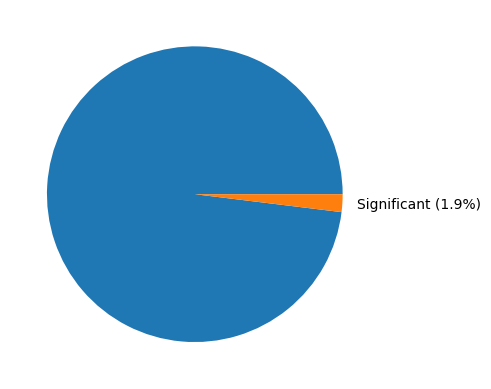

In [58]:
df.is_significant.value_counts()
fig, ax = plt.subplots()
ax.pie(df.is_significant.value_counts(), labels=['','Significant (1.9%)'])

In [5]:
X_train, X_test, y_train, y_test, X_train_resampled, y_train_resampled, X, y = supervised_preprocessing(df, 0.2)

## Class Weighting

Random Forest Classifier 

** Due to runtime, I'm using 3-fold cross validation

In [6]:
# rfc_cw_cv = cross_validate(RandomForestClassifier(class_weight='balanced', random_state=42), X, y, cv=3,
#                            scoring=['balanced_accuracy',
#                                     'precision_macro',
#                                     'recall_macro',
#                                     'f1_macro',
#                                     'average_precision',
#                                     'roc_auc'])

# dump(rfc_cw_cv, '../models/supervised/rfc_cw_cv.pkl.lzma')
rfc_cw_cv = load('../models/supervised/rfc_cw_cv.pkl.lzma')

In [7]:
print(f"Accuracy Mean: {np.mean(rfc_cw_cv['test_balanced_accuracy'])}")
print(f"Accuracy Standard Deviation: {np.std(rfc_cw_cv['test_balanced_accuracy'])}")

print(f"\nPrecision Mean: {np.mean(rfc_cw_cv['test_precision_macro'])}")
print(f"Precision Standard Deviation: {np.std(rfc_cw_cv['test_precision_macro'])}")

print(f"\nRecall Mean: {np.mean(rfc_cw_cv['test_recall_macro'])}")
print(f"Recall Standard Deviation: {np.std(rfc_cw_cv['test_recall_macro'])}")

print(f"\nF1 Mean: {np.mean(rfc_cw_cv['test_f1_macro'])}")
print(f"F1 Standard Deviation: {np.std(rfc_cw_cv['test_f1_macro'])}")

print(f"\nPR AUC Mean: {np.mean(rfc_cw_cv['test_average_precision'])}")
print(f"PR AUC Standard Deviation: {np.std(rfc_cw_cv['test_average_precision'])}")

print(f"\nROC AUC Mean: {np.mean(rfc_cw_cv['test_roc_auc'])}")
print(f"ROC AUC Standard Deviation: {np.std(rfc_cw_cv['test_roc_auc'])}")

Accuracy Mean: 0.4932398613915326
Accuracy Standard Deviation: 0.005972633422213331

Precision Mean: 0.5130540045505652
Precision Standard Deviation: 0.022686116453748996

Recall Mean: 0.4932398613915326
Recall Standard Deviation: 0.005972633422213331

F1 Mean: 0.490220542374187
F1 Standard Deviation: 0.006733066336403958

PR AUC Mean: 0.026473043820753692
PR AUC Standard Deviation: 0.0011150809991265845

ROC AUC Mean: 0.6159935427073039
ROC AUC Standard Deviation: 0.031239805467947846


Logistic Regression

In [8]:
# lr_cw_cv = cross_validate(LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), X, y, 
#                            scoring=['balanced_accuracy',
#                                     'precision_macro',
#                                     'recall_macro',
#                                     'f1_macro',
#                                     'average_precision',
#                                     'roc_auc'])

# dump(lr_cw_cv, '../models/supervised/lr_cw_cv.pkl.lzma')
lr_cw_cv = load('../models/supervised/lr_cw_cv.pkl.lzma')

In [9]:
print(f"Accuracy Mean: {np.mean(lr_cw_cv['test_balanced_accuracy'])}")
print(f"Accuracy Standard Deviation: {np.std(lr_cw_cv['test_balanced_accuracy'])}")

print(f"\nPrecision Mean: {np.mean(lr_cw_cv['test_precision_macro'])}")
print(f"Precision Standard Deviation: {np.std(lr_cw_cv['test_precision_macro'])}")

print(f"\nRecall Mean: {np.mean(lr_cw_cv['test_recall_macro'])}")
print(f"Recall Standard Deviation: {np.std(lr_cw_cv['test_recall_macro'])}")

print(f"\nF1 Mean: {np.mean(lr_cw_cv['test_f1_macro'])}")
print(f"F1 Standard Deviation: {np.std(lr_cw_cv['test_f1_macro'])}")

print(f"\nPR AUC Mean: {np.mean(lr_cw_cv['test_average_precision'])}")
print(f"PR AUC Standard Deviation: {np.std(lr_cw_cv['test_average_precision'])}")

print(f"\nROC AUC Mean: {np.mean(lr_cw_cv['test_roc_auc'])}")
print(f"ROC AUC Standard Deviation: {np.std(lr_cw_cv['test_roc_auc'])}")

Accuracy Mean: 0.5016593563570347
Accuracy Standard Deviation: 0.017818296859654786

Precision Mean: 0.5188842761927993
Precision Standard Deviation: 0.03038626593575798

Recall Mean: 0.5016593563570347
Recall Standard Deviation: 0.017818296859654786

F1 Mean: 0.45707514876140254
F1 Standard Deviation: 0.06218743126502341

PR AUC Mean: 0.02716368678017821
PR AUC Standard Deviation: 0.01794517032818868

ROC AUC Mean: 0.4756695506952847
ROC AUC Standard Deviation: 0.17762985598438757


Linear SVC

In [10]:
# svm_cw_cv = cross_validate(LinearSVC(class_weight='balanced', random_state=42), X, y, 
#                            scoring=[
#                                'balanced_accuracy',
#                                     'precision_macro',
#                                     'recall_macro',
#                                     'f1_macro',
#                                     'average_precision',
#                                     'roc_auc'])

# dump(svm_cw_cv, '../models/supervised/svm_cw_cv.pkl.lzma')
svm_cw_cv = load('../models/supervised/svm_cw_cv.pkl.lzma')

In [11]:
print(f"Accuracy Mean: {np.mean(svm_cw_cv['test_balanced_accuracy'])}")
print(f"Accuracy Standard Deviation: {np.std(svm_cw_cv['test_balanced_accuracy'])}")

print(f"\nPrecision Mean: {np.mean(svm_cw_cv['test_precision_macro'])}")
print(f"Precision Standard Deviation: {np.std(svm_cw_cv['test_precision_macro'])}")

print(f"\nRecall Mean: {np.mean(svm_cw_cv['test_recall_macro'])}")
print(f"Recall Standard Deviation: {np.std(svm_cw_cv['test_recall_macro'])}")

print(f"\nF1 Mean: {np.mean(svm_cw_cv['test_f1_macro'])}")
print(f"F1 Standard Deviation: {np.std(svm_cw_cv['test_f1_macro'])}")

print(f"\nPR AUC Mean: {np.mean(svm_cw_cv['test_average_precision'])}")
print(f"PR AUC Standard Deviation: {np.std(svm_cw_cv['test_average_precision'])}")

print(f"\nROC AUC Mean: {np.mean(svm_cw_cv['test_roc_auc'])}")
print(f"ROC AUC Standard Deviation: {np.std(svm_cw_cv['test_roc_auc'])}")

Accuracy Mean: 0.47698330616161844
Accuracy Standard Deviation: 0.029055712975655696

Precision Mean: 0.5128216612825126
Precision Standard Deviation: 0.024896053132305355

Recall Mean: 0.47698330616161844
Recall Standard Deviation: 0.029055712975655696

F1 Mean: 0.47700101019649327
F1 Standard Deviation: 0.03267416742901959

PR AUC Mean: 0.02216289634810734
PR AUC Standard Deviation: 0.011853997347108347

ROC AUC Mean: 0.42563159366831976
ROC AUC Standard Deviation: 0.144096741526181


## SMOTE

Random Forest Classifier

** Due to runtime, I'm using 3-fold cross validation

In [12]:
# pipeline = Pipeline([
#     ('oversample', SMOTE(random_state=42)),
#     ('clf', RandomForestClassifier(random_state=42))
# ])

# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# rfc_smote_cv = cross_validate(pipeline, X, y, cv=cv, scoring=['balanced_accuracy',
#                                     'precision_macro',
#                                     'recall_macro',
#                                     'f1_macro',
#                                     'average_precision',
#                                     'roc_auc'], return_train_score=False)

# dump(rfc_smote_cv, '../models/supervised/rfc_smote_cv.pkl.lzma')
rfc_smote_cv = load('../models/supervised/rfc_smote_cv.pkl.lzma')

In [13]:
print(f"Accuracy Mean: {np.mean(rfc_smote_cv['test_balanced_accuracy'])}")
print(f"Accuracy Standard Deviation: {np.std(rfc_smote_cv['test_balanced_accuracy'])}")

print(f"\nPrecision Mean: {np.mean(rfc_smote_cv['test_precision_macro'])}")
print(f"Precision Standard Deviation: {np.std(rfc_smote_cv['test_precision_macro'])}")

print(f"\nRecall Mean: {np.mean(rfc_smote_cv['test_recall_macro'])}")
print(f"Recall Standard Deviation: {np.std(rfc_smote_cv['test_recall_macro'])}")

print(f"\nF1 Mean: {np.mean(rfc_smote_cv['test_f1_macro'])}")
print(f"F1 Standard Deviation: {np.std(rfc_smote_cv['test_f1_macro'])}")

print(f"\nPR AUC Mean: {np.mean(rfc_smote_cv['test_average_precision'])}")
print(f"PR AUC Standard Deviation: {np.std(rfc_smote_cv['test_average_precision'])}")

print(f"\nROC AUC Mean: {np.mean(rfc_smote_cv['test_roc_auc'])}")
print(f"ROC AUC Standard Deviation: {np.std(rfc_smote_cv['test_roc_auc'])}")

Accuracy Mean: 0.5864763749125487
Accuracy Standard Deviation: 0.0005078176984367956

Precision Mean: 0.7664151498387303
Precision Standard Deviation: 0.009596204070967038

Recall Mean: 0.5864763749125487
Recall Standard Deviation: 0.0005078176984367956

F1 Mean: 0.6283775631218637
F1 Standard Deviation: 0.0012520857995671016

PR AUC Mean: 0.2989821216911039
PR AUC Standard Deviation: 0.0056752163849766515

ROC AUC Mean: 0.8902644528267928
ROC AUC Standard Deviation: 0.001849202883969802


Logistic Regression

In [14]:
# pipeline = Pipeline([
#     ('oversample', SMOTE(random_state=42)),
#     ('clf', LogisticRegression(random_state=42))
# ])

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# lr_smote_cv = cross_validate(pipeline, X, y, cv=cv, scoring=['balanced_accuracy',
#                                     'precision_macro',
#                                     'recall_macro',
#                                     'f1_macro',
#                                     'average_precision',
#                                     'roc_auc'], return_train_score=False)

# dump(lr_smote_cv, '../models/supervised/lr_smote_cv.pkl.lzma')
lr_smote_cv = load('../models/supervised/lr_smote_cv.pkl.lzma')

In [15]:
print(f"Accuracy Mean: {np.mean(lr_smote_cv['test_balanced_accuracy'])}")
print(f"Accuracy Standard Deviation: {np.std(lr_smote_cv['test_balanced_accuracy'])}")

print(f"\nPrecision Mean: {np.mean(lr_smote_cv['test_precision_macro'])}")
print(f"Precision Standard Deviation: {np.std(lr_smote_cv['test_precision_macro'])}")

print(f"\nRecall Mean: {np.mean(lr_smote_cv['test_recall_macro'])}")
print(f"Recall Standard Deviation: {np.std(lr_smote_cv['test_recall_macro'])}")

print(f"\nF1 Mean: {np.mean(lr_smote_cv['test_f1_macro'])}")
print(f"F1 Standard Deviation: {np.std(lr_smote_cv['test_f1_macro'])}")

print(f"\nPR AUC Mean: {np.mean(lr_smote_cv['test_average_precision'])}")
print(f"PR AUC Standard Deviation: {np.std(lr_smote_cv['test_average_precision'])}")

print(f"\nROC AUC Mean: {np.mean(lr_smote_cv['test_roc_auc'])}")
print(f"ROC AUC Standard Deviation: {np.std(lr_smote_cv['test_roc_auc'])}")

Accuracy Mean: 0.7466605035057909
Accuracy Standard Deviation: 0.004956216744074349

Precision Mean: 0.5795149244419566
Precision Standard Deviation: 0.0020396361683382683

Recall Mean: 0.7466605035057909
Recall Standard Deviation: 0.004956216744074349

F1 Mean: 0.612807772469447
F1 Standard Deviation: 0.0028889816732844743

PR AUC Mean: 0.27245931434016546
PR AUC Standard Deviation: 0.00650423991440922

ROC AUC Mean: 0.8977265003371638
ROC AUC Standard Deviation: 0.002992685954535112


Linear SVM

In [16]:
# pipeline = Pipeline([
#     ('oversample', SMOTE(random_state=42)),
#     ('clf', LinearSVC(random_state=42))
# ])

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# svm_smote_cv = cross_validate(pipeline, X, y, cv=cv, scoring=['balanced_accuracy',
#                                     'precision_macro',
#                                     'recall_macro',
#                                     'f1_macro',
#                                     'average_precision',
#                                     'roc_auc'], return_train_score=False)

# dump(svm_smote_cv, '../models/supervised/svm_smote_cv.pkl.lzma')
svm_smote_cv = load('../models/supervised/svm_smote_cv.pkl.lzma')

In [17]:
print(f"Accuracy Mean: {np.mean(svm_smote_cv['test_balanced_accuracy'])}")
print(f"Accuracy Standard Deviation: {np.std(svm_smote_cv['test_balanced_accuracy'])}")

print(f"\nPrecision Mean: {np.mean(svm_smote_cv['test_precision_macro'])}")
print(f"Precision Standard Deviation: {np.std(svm_smote_cv['test_precision_macro'])}")

print(f"\nRecall Mean: {np.mean(svm_smote_cv['test_recall_macro'])}")
print(f"Recall Standard Deviation: {np.std(svm_smote_cv['test_recall_macro'])}")

print(f"\nF1 Mean: {np.mean(svm_smote_cv['test_f1_macro'])}")
print(f"F1 Standard Deviation: {np.std(svm_smote_cv['test_f1_macro'])}")

print(f"\nPR AUC Mean: {np.mean(svm_smote_cv['test_average_precision'])}")
print(f"PR AUC Standard Deviation: {np.std(svm_smote_cv['test_average_precision'])}")

print(f"\nROC AUC Mean: {np.mean(svm_smote_cv['test_roc_auc'])}")
print(f"ROC AUC Standard Deviation: {np.std(svm_smote_cv['test_roc_auc'])}")

Accuracy Mean: 0.6257992039995308
Accuracy Standard Deviation: 0.001550819608458918

Precision Mean: 0.6149213150263664
Precision Standard Deviation: 0.0033769495594356226

Recall Mean: 0.6257992039995308
Recall Standard Deviation: 0.001550819608458918

F1 Mean: 0.6200311744128136
F1 Standard Deviation: 0.001328972477055785

PR AUC Mean: 0.17885116475159496
PR AUC Standard Deviation: 0.005361271243833402

ROC AUC Mean: 0.8272928920197404
ROC AUC Standard Deviation: 0.004443036877543403


## Undersampling

Random Forest Classifier

In [18]:
# pipeline = Pipeline([
#     ('undersample', RandomUnderSampler(random_state=42)),
#     ('clf', RandomForestClassifier(random_state=42))
# ])

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# rfc_und_cv = cross_validate(pipeline, X, y, cv=cv, scoring=['balanced_accuracy',
#                                     'precision_macro',
#                                     'recall_macro',
#                                     'f1_macro',
#                                     'average_precision',
#                                     'roc_auc'], return_train_score=False)

# dump(rfc_und_cv, '../models/supervised/rfc_und_cv.pkl.lzma')
rfc_und_cv = load('../models/supervised/rfc_und_cv.pkl.lzma')

In [19]:
print(f"Accuracy Mean: {np.mean(rfc_und_cv['test_balanced_accuracy'])}")
print(f"Accuracy Standard Deviation: {np.std(rfc_und_cv['test_balanced_accuracy'])}")

print(f"\nPrecision Mean: {np.mean(rfc_und_cv['test_precision_macro'])}")
print(f"Precision Standard Deviation: {np.std(rfc_und_cv['test_precision_macro'])}")

print(f"\nRecall Mean: {np.mean(rfc_und_cv['test_recall_macro'])}")
print(f"Recall Standard Deviation: {np.std(rfc_und_cv['test_recall_macro'])}")

print(f"\nF1 Mean: {np.mean(rfc_und_cv['test_f1_macro'])}")
print(f"F1 Standard Deviation: {np.std(rfc_und_cv['test_f1_macro'])}")

print(f"\nPR AUC Mean: {np.mean(rfc_und_cv['test_average_precision'])}")
print(f"PR AUC Standard Deviation: {np.std(rfc_und_cv['test_average_precision'])}")

print(f"\nROC AUC Mean: {np.mean(rfc_und_cv['test_roc_auc'])}")
print(f"ROC AUC Standard Deviation: {np.std(rfc_und_cv['test_roc_auc'])}")


Accuracy Mean: 0.82604644692326
Accuracy Standard Deviation: 0.001297176133474559

Precision Mean: 0.5399600455391184
Precision Standard Deviation: 0.0007432268300820613

Recall Mean: 0.82604644692326
Recall Standard Deviation: 0.001297176133474559

F1 Mean: 0.5262734709662873
F1 Standard Deviation: 0.002530742049530913

PR AUC Mean: 0.22658258200337933
PR AUC Standard Deviation: 0.008980805481413319

ROC AUC Mean: 0.9067127302755356
ROC AUC Standard Deviation: 0.0016491401105893577


Logistic Regression

In [20]:
pipeline = Pipeline([
    ('undersample', RandomUnderSampler(random_state=42)),
    ('clf', LogisticRegression(random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_und_cv = cross_validate(pipeline, X, y, cv=cv, scoring=['balanced_accuracy',
                                    'precision_macro',
                                    'recall_macro',
                                    'f1_macro',
                                    'average_precision',
                                    'roc_auc'], return_train_score=False)

In [21]:
print(f"Accuracy Mean: {np.mean(lr_und_cv['test_balanced_accuracy'])}")
print(f"Accuracy Standard Deviation: {np.std(lr_und_cv['test_balanced_accuracy'])}")

print(f"\nPrecision Mean: {np.mean(lr_und_cv['test_precision_macro'])}")
print(f"Precision Standard Deviation: {np.std(lr_und_cv['test_precision_macro'])}")

print(f"\nRecall Mean: {np.mean(lr_und_cv['test_recall_macro'])}")
print(f"Recall Standard Deviation: {np.std(lr_und_cv['test_recall_macro'])}")

print(f"\nF1 Mean: {np.mean(lr_und_cv['test_f1_macro'])}")
print(f"F1 Standard Deviation: {np.std(lr_und_cv['test_f1_macro'])}")

print(f"\nPR AUC Mean: {np.mean(lr_und_cv['test_average_precision'])}")
print(f"PR AUC Standard Deviation: {np.std(lr_und_cv['test_average_precision'])}")

print(f"\nROC AUC Mean: {np.mean(lr_und_cv['test_roc_auc'])}")
print(f"ROC AUC Standard Deviation: {np.std(lr_und_cv['test_roc_auc'])}")


Accuracy Mean: 0.8105248154439604
Accuracy Standard Deviation: 0.002647499256527303

Precision Mean: 0.5365305595373645
Precision Standard Deviation: 0.0006113731466736547

Recall Mean: 0.8105248154439604
Recall Standard Deviation: 0.002647499256527303

F1 Mean: 0.517375584816927
F1 Standard Deviation: 0.0018548666714718308

PR AUC Mean: 0.23341146214375694
PR AUC Standard Deviation: 0.0063532016030648985

ROC AUC Mean: 0.8926053040378316
ROC AUC Standard Deviation: 0.0020818741228893667


Linear SVC

In [22]:
pipeline = Pipeline([
    ('undersample', RandomUnderSampler(random_state=42)),
    ('clf', LinearSVC(random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_und_cv = cross_validate(pipeline, X, y, cv=cv, scoring=['balanced_accuracy',
                                    'precision_macro',
                                    'recall_macro',
                                    'f1_macro',
                                    'average_precision',
                                    'roc_auc'], return_train_score=False)

In [23]:
print(f"Accuracy Mean: {np.mean(svm_und_cv['test_balanced_accuracy'])}")
print(f"Accuracy Standard Deviation: {np.std(svm_und_cv['test_balanced_accuracy'])}")

print(f"\nPrecision Mean: {np.mean(svm_und_cv['test_precision_macro'])}")
print(f"Precision Standard Deviation: {np.std(svm_und_cv['test_precision_macro'])}")

print(f"\nRecall Mean: {np.mean(svm_und_cv['test_recall_macro'])}")
print(f"Recall Standard Deviation: {np.std(svm_und_cv['test_recall_macro'])}")

print(f"\nF1 Mean: {np.mean(svm_und_cv['test_f1_macro'])}")
print(f"F1 Standard Deviation: {np.std(svm_und_cv['test_f1_macro'])}")

print(f"\nPR AUC Mean: {np.mean(svm_und_cv['test_average_precision'])}")
print(f"PR AUC Standard Deviation: {np.std(svm_und_cv['test_average_precision'])}")

print(f"\nROC AUC Mean: {np.mean(svm_und_cv['test_roc_auc'])}")
print(f"ROC AUC Standard Deviation: {np.std(svm_und_cv['test_roc_auc'])}")

Accuracy Mean: 0.8120720895109864
Accuracy Standard Deviation: 0.0025834715810004066

Precision Mean: 0.5371143237939473
Precision Standard Deviation: 0.0005459145734275835

Recall Mean: 0.8120720895109864
Recall Standard Deviation: 0.0025834715810004066

F1 Mean: 0.5192426085486759
F1 Standard Deviation: 0.0016848891727158405

PR AUC Mean: 0.17884239691910747
PR AUC Standard Deviation: 0.0031794863175895346

ROC AUC Mean: 0.8913548366897611
ROC AUC Standard Deviation: 0.0026197932573098106


## Hyperparameter Tuning

Logistic Regression SMOTE - after running for hours this code threw an error when I tried to download the final object, but had printed out all of the results from 100 folds, so I looked through them to find the parameters with the best score.

In [24]:
# comment this cell out if importing model from pkl file

# lr_smote_tuning = LogisticRegression(random_state=42)

# param_dist = {
#     'C': [0.0001, 0.001, 0.01, 0.1, 1, 10],
#     'penalty': ['l1', 'l2'],
#     'solver': ['saga'],
#     'tol': [1e-4, 1e-3, 1e-2],
#     'max_iter': [1000, 5000, 10000]
# }


# lr_smote_search = RandomizedSearchCV(
#     estimator=lr_smote_tuning,
#     param_distributions=param_dist,
#     n_iter=20,
#     scoring=make_scorer(f1_score, average='macro'),
#     cv=5,
#     verbose=4,
#     random_state=42,
#     n_jobs=-1
# )

# lr_smote_search.fit(X_train_resampled, y_train_resampled)

In [25]:
# lr_best_model = LogisticRegression(random_state=42, C=1, max_iter=5000, penalty='l2', solver='saga', tol=0.0001).fit(X_train_resampled, y_train_resampled)
# dump(lr_best_model, '../models/supervised/lr_best_model.pkl.lzma')

In [26]:
lr_best_model = load('../models/supervised/lr_best_model.pkl.lzma')
lr_y_pred = lr_best_model.predict(X_test)

print("Best Parameters: C=1, max_iter=5000, penalty='l2', solver='saga', tol=0.0001")
print(f"Accuracy Score: {accuracy_score(y_test, lr_y_pred)}")
print(f"Precision Score: {precision_score(y_test, lr_y_pred,average='macro')}")
print(f"Recall Score: {recall_score(y_test, lr_y_pred,average='macro')}")
print(f"F1 Score: {f1_score(y_test, lr_y_pred, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_test, lr_y_pred)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, lr_y_pred)}")


Best Parameters: C=1, max_iter=5000, penalty='l2', solver='saga', tol=0.0001
Accuracy Score: 0.9199212306169581
Precision Score: 0.5662624296342826
Recall Score: 0.7701154486713235
F1 Score: 0.5933482177372339
PR AUC Score: 0.09388018142115517
ROC AUC Score: 0.7701154486713235


In [27]:
# pipeline = Pipeline([
#     ('oversample', SMOTE(random_state=42)),
#     ('clf', LogisticRegression(random_state=42, C=1, max_iter=5000, penalty='l2', solver='saga', tol=0.0001))
# ])

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# best_lr_smote_cv = cross_validate(pipeline, X, y, cv=cv, scoring=['balanced_accuracy',
#                                     'precision_macro',
#                                     'recall_macro',
#                                     'f1_macro',
#                                     'average_precision',
#                                     'roc_auc'], return_train_score=False)

# dump(best_lr_smote_cv, '../models/supervised/best_lr_smote_cv.pkl.lzma')
best_lr_smote_cv =  load('../models/supervised/best_lr_smote_cv.pkl.lzma')

In [28]:
print(f"Accuracy Mean: {np.mean(best_lr_smote_cv['test_balanced_accuracy'])}")
print(f"Accuracy Standard Deviation: {np.std(best_lr_smote_cv['test_balanced_accuracy'])}")
print(f"Accuracy Variance: {np.var(best_lr_smote_cv['test_balanced_accuracy'])}")

print(f"\nPrecision Mean: {np.mean(best_lr_smote_cv['test_precision_macro'])}")
print(f"Precision Standard Deviation: {np.std(best_lr_smote_cv['test_precision_macro'])}")
print(f"Precision Variance: {np.var(best_lr_smote_cv['test_precision_macro'])}")

print(f"\nRecall Mean: {np.mean(best_lr_smote_cv['test_recall_macro'])}")
print(f"Recall Standard Deviation: {np.std(best_lr_smote_cv['test_recall_macro'])}")
print(f"Recall Variance: {np.var(best_lr_smote_cv['test_recall_macro'])}")

print(f"\nF1 Mean: {np.mean(best_lr_smote_cv['test_f1_macro'])}")
print(f"F1 Standard Deviation: {np.std(best_lr_smote_cv['test_f1_macro'])}")
print(f"F1 Variance: {np.var(best_lr_smote_cv['test_f1_macro'])}")

print(f"\nPR AUC Mean: {np.mean(best_lr_smote_cv['test_average_precision'])}")
print(f"PR AUC Standard Deviation: {np.std(best_lr_smote_cv['test_average_precision'])}")
print(f"PR AUC Variance: {np.var(best_lr_smote_cv['test_average_precision'])}")

print(f"\nROC AUC Mean: {np.mean(best_lr_smote_cv['test_roc_auc'])}")
print(f"ROC AUC Standard Deviation: {np.std(best_lr_smote_cv['test_roc_auc'])}")
print(f"ROC AUC Variance: {np.var(best_lr_smote_cv['test_roc_auc'])}")

Accuracy Mean: 0.7734353018956837
Accuracy Standard Deviation: 0.01180243836200848
Accuracy Variance: 0.00013929755128900943

Precision Mean: 0.5698793798016314
Precision Standard Deviation: 0.007719140117290141
Precision Variance: 5.958512415035805e-05

Recall Mean: 0.7734353018956837
Recall Standard Deviation: 0.01180243836200848
Recall Variance: 0.00013929755128900943

F1 Mean: 0.5982951235214221
F1 Standard Deviation: 0.011181131376523552
F1 Variance: 0.00012501769885907947

PR AUC Mean: 0.2898143422976457
PR AUC Standard Deviation: 0.007197372944039995
PR AUC Variance: 5.180217729559894e-05

ROC AUC Mean: 0.9056812711710425
ROC AUC Standard Deviation: 0.002076469408041843
ROC AUC Variance: 4.311725202533641e-06


Linear SVC SMOTE

In [29]:
# comment this cell out if importing model from pkl file

# svm_smote_tuning = LinearSVC(random_state=42, dual=False)

# param_dist = {
#     'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
#     'penalty': ['l1', 'l2'],
#     'max_iter': [1000, 5000, 10000],
#     'tol': [1e-4, 1e-3, 1e-2]
# }

# svm_smote_search = RandomizedSearchCV(
#     estimator=svm_smote_tuning,
#     param_distributions=param_dist,
#     n_iter=20,
#     scoring=make_scorer(f1_score, average='macro'),
#     cv=5,
#     verbose=4,
#     random_state=42,
#     n_jobs=-1
# )

# svm_smote_search.fit(X_train_resampled, y_train_resampled)

# dump(svm_smote_search, '../models/supervised/svm_smote_search.pkl.lzma')
svm_smote_search = load('../models/supervised/svm_smote_search.pkl.lzma')

In [30]:
svm_best_model = svm_smote_search.best_estimator_
svm_y_pred = svm_best_model.predict(X_test)

print("Best Parameters:", svm_smote_search.best_params_)
print(f"Accuracy Score: {accuracy_score(y_test, svm_y_pred)}")
print(f"Precision Score: {precision_score(y_test, svm_y_pred,average='macro')}")
print(f"Recall Score: {recall_score(y_test, svm_y_pred,average='macro')}")
print(f"F1 Score: {f1_score(y_test, svm_y_pred, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_test, svm_y_pred)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, svm_y_pred)}")

Best Parameters: {'tol': 0.0001, 'penalty': 'l1', 'max_iter': 5000, 'C': 1}
Accuracy Score: 0.9721832728472452
Precision Score: 0.6169154092124062
Recall Score: 0.6022234699990654
F1 Score: 0.609024520388546
PR AUC Score: 0.06932163361987387
ROC AUC Score: 0.6022234699990655


In [31]:
# pipeline = Pipeline([
#     ('oversample', SMOTE(random_state=42)),
#     ('clf', LinearSVC(random_state=42, tol=0.0001, penalty='l1', max_iter=5000, C=1))
# ])

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# best_svm_smote_cv = cross_validate(pipeline, X, y, cv=cv, scoring=['balanced_accuracy',
#                                     'precision_macro',
#                                     'recall_macro',
#                                     'f1_macro',
#                                     'average_precision',
#                                     'roc_auc'], return_train_score=False)

# dump(best_svm_smote_cv, '../models/supervised/best_svm_smote_cv.pkl.lzma')
best_svm_smote_cv = load('../models/supervised/best_svm_smote_cv.pkl.lzma')

In [32]:
print(f"Accuracy Mean: {np.mean(best_svm_smote_cv['test_balanced_accuracy'])}")
print(f"Accuracy Standard Deviation: {np.std(best_svm_smote_cv['test_balanced_accuracy'])}")
print(f"Accuracy Variance: {np.var(best_svm_smote_cv['test_balanced_accuracy'])}")

print(f"\nPrecision Mean: {np.mean(best_svm_smote_cv['test_precision_macro'])}")
print(f"Precision Standard Deviation: {np.std(best_svm_smote_cv['test_precision_macro'])}")
print(f"Precision Variance: {np.var(best_svm_smote_cv['test_precision_macro'])}")

print(f"\nRecall Mean: {np.mean(best_svm_smote_cv['test_recall_macro'])}")
print(f"Recall Standard Deviation: {np.std(best_svm_smote_cv['test_recall_macro'])}")
print(f"Recall Variance: {np.var(best_svm_smote_cv['test_recall_macro'])}")

print(f"\nF1 Mean: {np.mean(best_svm_smote_cv['test_f1_macro'])}")
print(f"F1 Standard Deviation: {np.std(best_svm_smote_cv['test_f1_macro'])}")
print(f"F1 Variance: {np.var(best_svm_smote_cv['test_f1_macro'])}")

print(f"\nPR AUC Mean: {np.mean(best_svm_smote_cv['test_average_precision'])}")
print(f"PR AUC Standard Deviation: {np.std(best_svm_smote_cv['test_average_precision'])}")
print(f"PR AUC Variance: {np.var(best_svm_smote_cv['test_average_precision'])}")

print(f"\nROC AUC Mean: {np.mean(best_svm_smote_cv['test_roc_auc'])}")
print(f"ROC AUC Standard Deviation: {np.std(best_svm_smote_cv['test_roc_auc'])}")
print(f"ROC AUC Variance: {np.var(best_svm_smote_cv['test_roc_auc'])}")

Accuracy Mean: 0.6051182632115812
Accuracy Standard Deviation: 0.0022109654890215993
Accuracy Variance: 4.88836839364452e-06

Precision Mean: 0.6156356598909432
Precision Standard Deviation: 0.005629951616120352
Precision Variance: 3.1696355199856164e-05

Recall Mean: 0.6051182632115812
Recall Standard Deviation: 0.0022109654890215993
Recall Variance: 4.88836839364452e-06

F1 Mean: 0.6100504371261445
F1 Standard Deviation: 0.003414023711743753
F1 Variance: 1.1655557904348592e-05

PR AUC Mean: 0.17136073688960135
PR AUC Standard Deviation: 0.007139382769030726
PR AUC Variance: 5.097078632273283e-05

ROC AUC Mean: 0.7930633160857176
ROC AUC Standard Deviation: 0.005885488516703419
ROC AUC Variance: 3.4638975080247817e-05


### Best model: Logistic Regression
### Best parameters: C=1, max_iter=5000, penalty='l2', solver='saga', tol=0.0001

## Training data curves

20% training set

In [33]:
# X_train, X_test, y_train, y_test, X_train_resampled, y_train_resampled, X, y = supervised_preprocessing(df, 0.8)
# clf_20 = LogisticRegression(random_state=42,C=1, max_iter=5000, penalty='l2', solver='saga', tol=0.0001).fit(X_train_resampled, y_train_resampled)
# dump(clf_20, '../models/supervised/clf_20.pkl.lzma')
clf_20 = load('../models/supervised/clf_20.pkl.lzma')

In [34]:
y_pred20 = clf_20.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred20)}")
print(f"Precision Score: {precision_score(y_test, y_pred20,average='macro')}")
print(f"Recall Score: {recall_score(y_test, y_pred20,average='macro')}")
print(f"F1 Score: {f1_score(y_test, y_pred20, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_test, y_pred20)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred20)}")

Accuracy Score: 0.9363349554602441
Precision Score: 0.5667007462566445
Recall Score: 0.7053690607150231
F1 Score: 0.5936195150286172
PR AUC Score: 0.0775313320008371
ROC AUC Score: 0.7053690607150231


40% training set

In [35]:
# X_train, X_test, y_train, y_test, X_train_resampled, y_train_resampled, X, y = supervised_preprocessing(df, 0.6)
# clf_40 = LogisticRegression(random_state=42,C=1, max_iter=5000, penalty='l2', solver='saga', tol=0.0001).fit(X_train_resampled, y_train_resampled)
# dump(clf_40, '../models/supervised/clf_40.pkl.lzma')
clf_40 = load('../models/supervised/clf_40.pkl.lzma')

In [36]:
y_pred40 = clf_40.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred40)}")
print(f"Precision Score: {precision_score(y_test, y_pred40,average='macro')}")
print(f"Recall Score: {recall_score(y_test, y_pred40,average='macro')}")
print(f"F1 Score: {f1_score(y_test, y_pred40, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_test, y_pred40)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred40)}")

Accuracy Score: 0.9289013526888815
Precision Score: 0.5664179062550043
Recall Score: 0.7350030055028863
F1 Score: 0.5938680125922375
PR AUC Score: 0.08506515989359135
ROC AUC Score: 0.7350030055028863


60% training set

In [37]:
# X_train, X_test, y_train, y_test, X_train_resampled, y_train_resampled, X, y = supervised_preprocessing(df, 0.4)
# clf_60 = LogisticRegression(random_state=42,C=1, max_iter=5000, penalty='l2', solver='saga', tol=0.0001).fit(X_train_resampled, y_train_resampled)
# dump(clf_60, '../models/supervised/clf_60.pkl.lzma')
clf_60 = load('../models/supervised/clf_60.pkl.lzma')

In [38]:
y_pred60 = clf_60.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred60)}")
print(f"Precision Score: {precision_score(y_test, y_pred60,average='macro')}")
print(f"Recall Score: {recall_score(y_test, y_pred60,average='macro')}")
print(f"F1 Score: {f1_score(y_test, y_pred60, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_test, y_pred60)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred60)}")

Accuracy Score: 0.923478225008248
Precision Score: 0.5650980124490566
Recall Score: 0.7502556070769952
F1 Score: 0.591778947744981
PR AUC Score: 0.08769082770122791
ROC AUC Score: 0.7502556070769951


In [61]:
training_curve = {'percent':['20%','40%','60%','80%'],
            #    'accuracy':[accuracy_score(y_test, y_pred20),accuracy_score(y_test, y_pred40),accuracy_score(y_test, y_pred60),np.mean(best_lr_smote_cv['test_balanced_accuracy'])],
               'precision':[precision_score(y_test, y_pred20,average='macro'),precision_score(y_test, y_pred40,average='macro'),precision_score(y_test, y_pred60,average='macro'),np.mean(best_lr_smote_cv['test_precision_macro'])],
               'recall':[recall_score(y_test, y_pred20,average='macro'),recall_score(y_test, y_pred40,average='macro'),recall_score(y_test, y_pred60,average='macro'),np.mean(best_lr_smote_cv['test_recall_macro'])],
               'f1':[f1_score(y_test, y_pred20, average='macro'),f1_score(y_test, y_pred40, average='macro'),f1_score(y_test, y_pred60, average='macro'),np.mean(best_lr_smote_cv['test_f1_macro'])],
               'pr_auc':[average_precision_score(y_test, y_pred20),average_precision_score(y_test, y_pred40),average_precision_score(y_test, y_pred60),np.mean(best_lr_smote_cv['test_average_precision'])],
            #    'roc_auc':[roc_auc_score(y_test, y_pred20),roc_auc_score(y_test, y_pred40),roc_auc_score(y_test, y_pred60),np.mean(best_lr_smote_cv['test_roc_auc'])]
               }

training_curve_df = pd.DataFrame(training_curve).set_index('percent')
training_curve_df

,precision,recall,f1,pr_auc
percent,,,,
20%,0.56670%,0.70537%,0.59362%,0.07753%
40%,0.56642%,0.73500%,0.59387%,0.08507%
60%,0.56510%,0.75026%,0.59178%,0.08769%
80%,0.56988%,0.77344%,0.59830%,0.28981%


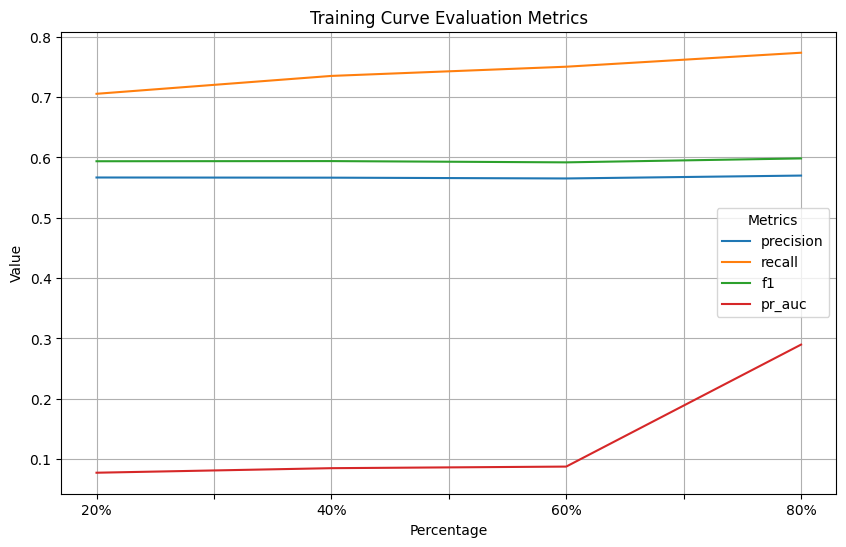

In [62]:
training_curve_df.plot(kind='line', figsize=(10, 6))
plt.title('Training Curve Evaluation Metrics')
plt.xlabel('Percentage')
plt.ylabel('Value')
plt.legend(title='Metrics')
plt.grid(True)
plt.show()

### Ablation testing

In [41]:
pd.options.display.float_format = '{:.5f}%'.format
print(supervised_feature_importance(lr_best_model))

                feature  importance
2                 title    0.37531%
6                medium    0.21869%
4   artist_display_name    0.18175%
1           object_name    0.13915%
8               culture    0.05117%
9    artist_nationality    0.02177%
3             portfolio    0.00639%
5        country_mapped    0.00374%
0            department    0.00101%
7         artist_gender    0.00099%
11                  age    0.00002%
10          access_year    0.00000%


In [42]:
# dropped title
X_train, X_test, y_train, y_test, X_train_resampled, y_train_resampled, X, y = ablation_testing(df, 
                                                                                                        ['department','object_name','portfolio',
                                                                                                         'artist_display_name','country_mapped',
                                                                                                         'medium', 'artist_gender','culture',
                                                                                                         'artist_nationality',], 0.2)
# clf_ab1 = LogisticRegression(random_state=42,C=1, max_iter=5000, penalty='l2', solver='saga', tol=0.0001).fit(X_train_resampled, y_train_resampled)
# dump(clf_ab1, '../models/supervised/clf_ab1.pkl.lzma')
clf_ab1 = load('../models/supervised/clf_ab1.pkl.lzma')

In [43]:
y_pred_ab1 = clf_ab1.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_ab1)}")
print(f"Precision Score: {precision_score(y_test, y_pred_ab1,average='macro')}")
print(f"Recall Score: {recall_score(y_test, y_pred_ab1,average='macro')}")
print(f"F1 Score: {f1_score(y_test, y_pred_ab1, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_test, y_pred_ab1)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_ab1)}")

Accuracy Score: 0.8987236060706038
Precision Score: 0.5554067207699491
Recall Score: 0.7796752863811693
F1 Score: 0.5731725314034518
PR AUC Score: 0.08422869245442968
ROC AUC Score: 0.7796752863811692


In [44]:
# dropped title, medium
X_train, X_test, y_train, y_test, X_train_resampled, y_train_resampled, X, y = ablation_testing(df, 
                                                                                                        ['department','object_name','portfolio',
                                                                                                         'artist_display_name','country_mapped',
                                                                                                         'artist_gender','culture',
                                                                                                         'artist_nationality',], 0.2)
# clf_ab2 = LogisticRegression(random_state=42,C=1, max_iter=5000, penalty='l2', solver='saga', tol=0.0001).fit(X_train_resampled, y_train_resampled)
# dump(clf_ab2, '../models/supervised/clf_ab2.pkl.lzma')
clf_ab2 = load('../models/supervised/clf_ab2.pkl.lzma')

In [45]:
y_pred_ab2 = clf_ab2.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_ab2)}")
print(f"Precision Score: {precision_score(y_test, y_pred_ab2,average='macro')}")
print(f"Recall Score: {recall_score(y_test, y_pred_ab2,average='macro')}")
print(f"F1 Score: {f1_score(y_test, y_pred_ab2, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_test, y_pred_ab2)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_ab2)}")

Accuracy Score: 0.8794952161002969
Precision Score: 0.5468361906619361
Recall Score: 0.7732659993142361
F1 Score: 0.5552526155815263
PR AUC Score: 0.07356209446852657
ROC AUC Score: 0.7732659993142361


In [46]:
# dropped title, medium, artist_display_name
X_train, X_test, y_train, y_test, X_train_resampled, y_train_resampled, X, y = ablation_testing(df,['department','object_name','portfolio',
                                                                                                    'country_mapped','artist_gender',
                                                                                                    'culture','artist_nationality',], 0.2)
# clf_ab3 = LogisticRegression(random_state=42,C=1, max_iter=5000, penalty='l2', solver='saga', tol=0.0001).fit(X_train_resampled, y_train_resampled)
# dump(clf_ab3, '../models/supervised/clf_ab3.pkl.lzma')
clf_ab3 = load('../models/supervised/clf_ab3.pkl.lzma')

In [47]:
y_pred_ab3 = clf_ab3.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_ab3)}")
print(f"Precision Score: {precision_score(y_test, y_pred_ab3,average='macro')}")
print(f"Recall Score: {recall_score(y_test, y_pred_ab3,average='macro')}")
print(f"F1 Score: {f1_score(y_test, y_pred_ab3, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_test, y_pred_ab3)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_ab3)}")

Accuracy Score: 0.855132382052128
Precision Score: 0.5391602429701429
Recall Score: 0.7652833315563297
F1 Score: 0.5364874748478352
PR AUC Score: 0.06399671802017555
ROC AUC Score: 0.7652833315563295


In [59]:
ablation = {'dropped':['title','medium','artist_display_name'],
            # 'accuracy':[accuracy_score(y_test, y_pred_ab1),accuracy_score(y_test, y_pred_ab2),accuracy_score(y_test, y_pred_ab3)],
            'precision':[precision_score(y_test, y_pred_ab1,average='macro'),precision_score(y_test, y_pred_ab2,average='macro'),precision_score(y_test, y_pred_ab3,average='macro')],
            'recall':[recall_score(y_test, y_pred_ab1,average='macro'),recall_score(y_test, y_pred_ab2,average='macro'),recall_score(y_test, y_pred_ab3,average='macro')],
            'f1':[f1_score(y_test, y_pred_ab1, average='macro'),f1_score(y_test, y_pred_ab2, average='macro'),f1_score(y_test, y_pred_ab3, average='macro')],
            'pr_auc':[average_precision_score(y_test, y_pred_ab1),average_precision_score(y_test, y_pred_ab2),average_precision_score(y_test, y_pred_ab3)],
            # 'roc_auc':[roc_auc_score(y_test, y_pred_ab1),roc_auc_score(y_test, y_pred_ab2),roc_auc_score(y_test, y_pred_ab3)]
            }

ablation_df = pd.DataFrame(ablation).set_index('dropped')
ablation_df

,precision,recall,f1,pr_auc
dropped,,,,
title,0.55541%,0.77968%,0.57317%,0.08423%
medium,0.54684%,0.77327%,0.55525%,0.07356%
artist_display_name,0.53916%,0.76528%,0.53649%,0.06400%


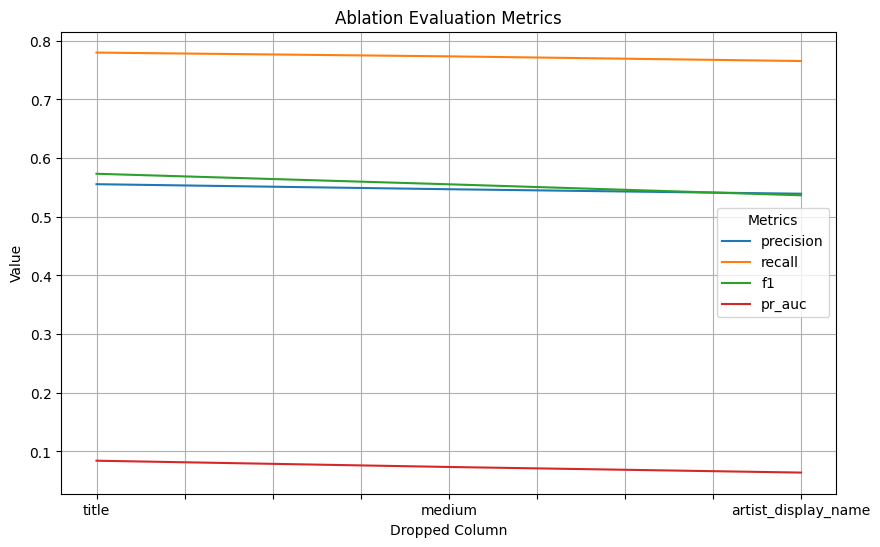

In [60]:
ablation_df.plot(kind='line', figsize=(10, 6))
plt.title('Ablation Evaluation Metrics')
plt.xlabel('Dropped Column')
plt.ylabel('Value')
plt.legend(title='Metrics')
plt.grid(True)
plt.show()

## Model of Choice

In [50]:
clf = lr_best_model
y_pred = lr_y_pred
X_train, X_test, y_train, y_test, X_train_resampled, y_train_resampled, X, y = supervised_preprocessing(df, 0.2)

In [51]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"Precision Score: {precision_score(y_test, y_pred,average='macro')}")
print(f"Recall Score: {recall_score(y_test, y_pred,average='macro')}")
print(f"F1 Score: {f1_score(y_test, y_pred, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_test, y_pred)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred)}")

Accuracy Score: 0.9199212306169581
Precision Score: 0.5662624296342826
Recall Score: 0.7701154486713235
F1 Score: 0.5933482177372339
PR AUC Score: 0.09388018142115517
ROC AUC Score: 0.7701154486713235


In [52]:
pd.options.display.float_format = '{:.5f}%'.format
print(supervised_feature_importance(clf))

                feature  importance
2                 title    0.37531%
6                medium    0.21869%
4   artist_display_name    0.18175%
1           object_name    0.13915%
8               culture    0.05117%
9    artist_nationality    0.02177%
3             portfolio    0.00639%
5        country_mapped    0.00374%
0            department    0.00101%
7         artist_gender    0.00099%
11                  age    0.00002%
10          access_year    0.00000%


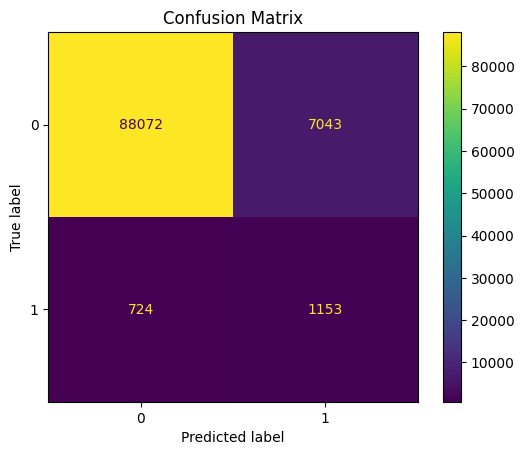

True negative: 88072
True positive: 1153
False negative: 724
False positive: 7043


In [53]:
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot()
plt.title('Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm.ravel().tolist()
print(f"True negative: {tn}")
print(f"True positive: {tp}")
print(f"False negative: {fn}")
print(f"False positive: {fp}")

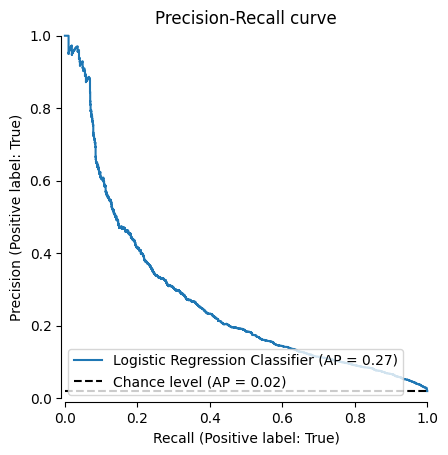

In [54]:
display = PrecisionRecallDisplay.from_estimator(
    clf, X_test, y_test, name="Logistic Regression Classifier", plot_chance_level=True, despine=True
)
_ = display.ax_.set_title("Precision-Recall curve")

### Failures

In [55]:
failure_df = pd.DataFrame({'test':y_test,'pred':y_pred})
false_neg = failure_df[failure_df.test & ~failure_df.pred][:5].index
false_pos = failure_df[~failure_df.test & failure_df.pred][:5].index

## False negatives

In [56]:
df.loc[false_neg]

,is_significant,department,object_name,title,portfolio,artist_display_name,country_mapped,medium,artist_gender,culture,artist_nationality,access_year,age
object_id,,,,,,,,,,,,,
459206,True,Robert Lehman Collection,Tondo mirror frame,Tondo mirror frame,NaN,"Italian, Siena",Italy,"Poplar; carved, gilt; deep red-brown bole.",NaN,"Italian, Siena",,1975,538
546742,True,Egyptian Art,"Amulet, fish",Fish Pendant,NaN,NaN,Egypt,"Turquoise, gold",NaN,NaN,NaN,1909,3903
255574,True,Greek and Roman Art,Volute-krater of Chalcidian shape,Terracotta volute-krater (vase for mixing wine...,NaN,Sophilos,Greece,Terracotta,NaN,"Greek, Attic",,1977,2624
229097,True,European Sculpture and Decorative Arts,Tapestry,The Gardener from a set of the Italian Village...,NaN,Beauvais|François Boucher|André Charlemagne Ch...,France,"Wool, silk (21-23 warps per inch, 8-9 per cm.)",|||,"French, Beauvais",|French|French|,1964,291
43951,True,Asian Art,Musical stone,NaN,NaN,NaN,China,Jade,NaN,China,NaN,1902,289


## False positives

In [57]:
df.loc[false_pos]

,is_significant,department,object_name,title,portfolio,artist_display_name,country_mapped,medium,artist_gender,culture,artist_nationality,access_year,age
object_id,,,,,,,,,,,,,
3879,False,The American Wing,Chandelier,Chandelier,NaN,"Mitchell, Vance & Co.",United States,Brass,NaN,American,,1968,157
8025,False,The American Wing,Sugar Bowl,Sugar Bowl,NaN,Joseph Lownes,United States,Silver,NaN,American,American,1933,228
659672,False,Drawings and Prints,Print,"New Inventions of Modern Times [Nova Reperta],...",NaN,"Jan van der Straet, called Stradanus|Jan Colla...",Netherlands,Engraving,||,NaN,Netherlandish|Netherlandish|Netherlandish,1949,430
38214,False,Asian Art,Bust,NaN,NaN,NaN,Pakistan,Schist,NaN,Pakistan (ancient region of Gandhara),NaN,1987,1825
199616,False,European Sculpture and Decorative Arts,Plaque,Christ Delivered to the People,NaN,Suzanne de Court,France,"Painted enamel on copper, partly gilded and si...",Female,"French, Limoges",French,1945,440
